<a href="https://colab.research.google.com/github/MariyaLy13/viral-prediction-ml-project/blob/main/MODEL_NEWS_ML_SUMMER_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.1 MB/s eta 0:00:00


In [4]:
import joblib
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import os
import pandas as pd
import seaborn as sns
import time
import torch
import torch.nn as nn
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, f1_score, mean_squared_error, roc_auc_score, roc_curve
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, BertTokenizerFast, BertModel, DistilBertModel, get_linear_schedule_with_warmup

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [6]:
# Load indices
train_idx = np.load("/content/drive/MyDrive/Python/ml/data/train_idx.npy")
val_idx   = np.load("/content/drive/MyDrive/Python/ml/data/val_idx.npy")
test_idx  = np.load("/content/drive/MyDrive/Python/ml/data/test_idx.npy")

# Load TF-IDF + numeric
X_tfidf_train = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_tfidf_train.npz")
X_tfidf_val   = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_tfidf_val.npz")
X_tfidf_test  = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_tfidf_test.npz")

# Load embeddings + numeric
X_emb_train = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_emb_train.npz")
X_emb_val   = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_emb_val.npz")
X_emb_test  = sparse.load_npz("/content/drive/MyDrive/Python/ml/data/X_emb_test.npz")

# Load numeric
X_num_train = np.load("/content/drive/MyDrive/Python/ml/data/X_num_train.npy", allow_pickle=True)
X_num_val = np.load("/content/drive/MyDrive/Python/ml/data/X_num_val.npy", allow_pickle=True)
X_num_test = np.load("/content/drive/MyDrive/Python/ml/data/X_num_test.npy", allow_pickle=True)

# Load text
X_text_train = np.load("/content/drive/MyDrive/Python/ml/data/X_text_train.npy", allow_pickle=True)
X_text_val = np.load("/content/drive/MyDrive/Python/ml/data/X_text_val.npy", allow_pickle=True)
X_text_test = np.load("/content/drive/MyDrive/Python/ml/data/X_text_test.npy", allow_pickle=True)

# Load targets
y_fb_train = np.load("/content/drive/MyDrive/Python/ml/data/y_fb_train.npy")
y_fb_val   = np.load("/content/drive/MyDrive/Python/ml/data/y_fb_val.npy")
y_fb_test  = np.load("/content/drive/MyDrive/Python/ml/data/y_fb_test.npy")

y_gp_train = np.load("/content/drive/MyDrive/Python/ml/data/y_gp_train.npy")
y_gp_val   = np.load("/content/drive/MyDrive/Python/ml/data/y_gp_val.npy")
y_gp_test  = np.load("/content/drive/MyDrive/Python/ml/data/y_gp_test.npy")

y_li_train = np.load("/content/drive/MyDrive/Python/ml/data/y_li_train.npy")
y_li_val   = np.load("/content/drive/MyDrive/Python/ml/data/y_li_val.npy")
y_li_test  = np.load("/content/drive/MyDrive/Python/ml/data/y_li_test.npy")

# Viral labels
y_viral_train = np.load("/content/drive/MyDrive/Python/ml/data/y_viral_train.npy")
y_viral_val   = np.load("/content/drive/MyDrive/Python/ml/data/y_viral_val.npy")
y_viral_test  = np.load("/content/drive/MyDrive/Python/ml/data/y_viral_test.npy")

### Baseline модель

Використовує: TF‑IDF + numeric

Модель 1: класифікація is_viral (LogReg)

Модель 2: регресія log1p(target)

### Logistic Regression - класифікація is_viral

In [18]:
clf_base = LogisticRegression(
    max_iter=500,
    n_jobs=-1
)

clf_base.fit(X_tfidf_train, y_viral_train)

# Predictions
viral_pred_train = clf_base.predict(X_tfidf_train)
viral_pred_val = clf_base.predict(X_tfidf_val)
viral_pred_test = clf_base.predict(X_tfidf_test)

# Metrics
log_reg_f1_train = f1_score(y_viral_train, viral_pred_train)
log_reg_auc_train = roc_auc_score(y_viral_train, clf_base.predict_proba(X_tfidf_train)[:,1])
log_reg_f1_val = f1_score(y_viral_val, viral_pred_val)
log_reg_auc_val = roc_auc_score(y_viral_val, clf_base.predict_proba(X_tfidf_val)[:,1])
log_reg_f1_test = f1_score(y_viral_test, viral_pred_test)
log_reg_auc_test = roc_auc_score(y_viral_test, clf_base.predict_proba(X_tfidf_test)[:,1])

print("Baseline Train F1:", log_reg_f1_train)
print("Baseline Train AUC:", log_reg_auc_train)
print("Baseline Val F1:", log_reg_f1_val)
print("Baseline Val AUC:", log_reg_auc_val)
print("Baseline Test F1:", log_reg_f1_test)
print("Baseline Test AUC:", log_reg_auc_test)

joblib.dump(clf_base, "/content/drive/MyDrive/Python/ml/data/viral_classifier.pkl")

Baseline Train F1: 0.45803513337670787
Baseline Train AUC: 0.9299722091791023
Baseline Val F1: 0.3280531425651507
Baseline Val AUC: 0.8670005762730492
Baseline Test F1: 0.32963709677419356
Baseline Test AUC: 0.8684150769486716


['/content/drive/MyDrive/Python/ml/data/viral_classifier.pkl']

### Вибираємо тільки viral samples

In [7]:
train_mask = y_viral_train == 1
val_mask   = y_viral_val == 1
test_mask  = y_viral_test == 1

In [8]:
X_tfidf_train_reg = X_tfidf_train[train_mask]
X_tfidf_val_reg   = X_tfidf_val[val_mask]
X_tfidf_test_reg  = X_tfidf_test[test_mask]

y_fb_train_reg = y_fb_train[train_mask]
y_fb_val_reg   = y_fb_val[val_mask]
y_fb_test_reg  = y_fb_test[test_mask]

### Linear Regression — регресія Facebook_log

In [21]:
reg_fb_base = LinearRegression()
reg_fb_base.fit(X_tfidf_train_reg, y_fb_train_reg)

joblib.dump(reg_fb_base, "/content/drive/MyDrive/Python/ml/data/regressor_fb_base.pkl")

['/content/drive/MyDrive/Python/ml/data/regressor_fb_base.pkl']

### Інференс (класифікація + регресія)

In [23]:
clf_base = joblib.load("/content/drive/MyDrive/Python/ml/data/viral_classifier.pkl")
reg_fb_base = joblib.load("/content/drive/MyDrive/Python/ml/data/regressor_fb_base.pkl")

In [24]:
# Step 1: predict viral (train)
viral_train_pred = clf_base.predict(X_tfidf_train)

# Step 2: regression only for viral=1
fb_pred_log_train = np.zeros_like(y_fb_train)
fb_pred_log_train[viral_train_pred == 1] = reg_fb_base.predict(X_tfidf_train[viral_train_pred == 1])

# Step 3: inverse log
fb_pred_train_original = np.expm1(fb_pred_log_train)
y_fb_train_original = np.expm1(y_fb_train)

# Step 4: RMSE
rmse_base_train = np.sqrt(mean_squared_error(y_fb_train_original, fb_pred_train_original))
print("Baseline RMSE (train):", rmse_base_train)

Baseline RMSE (train): 2192539.346638191


In [25]:
viral_val_pred = clf_base.predict(X_tfidf_val)

fb_pred_log_val = np.zeros_like(y_fb_val)
fb_pred_log_val[viral_val_pred == 1] = reg_fb_base.predict(X_tfidf_val[viral_val_pred == 1])

fb_pred_val_original = np.expm1(fb_pred_log_val)
y_fb_val_original = np.expm1(y_fb_val)

rmse_base_val = np.sqrt(mean_squared_error(y_fb_val_original, fb_pred_val_original))
print("Baseline RMSE (val):", rmse_base_val)

Baseline RMSE (val): 8444.585854372428


In [26]:
viral_test_pred = clf_base.predict(X_tfidf_test)

fb_pred_log_test = np.zeros_like(y_fb_test)
fb_pred_log_test[viral_test_pred == 1] = reg_fb_base.predict(X_tfidf_test[viral_test_pred == 1])

fb_pred_test_original = np.expm1(fb_pred_log_test)
y_fb_test_original = np.expm1(y_fb_test)

rmse_base_test = np.sqrt(mean_squared_error(y_fb_test_original, fb_pred_test_original))
print("Baseline RMSE (test):", rmse_base_test)

Baseline RMSE (test): 77707033.05212593


Модель 2 - LGBM

Використовує:
TF‑IDF + numeric або embeddings + numeric

Гіперпараметри (Optuna):
- LGBMClassifier
- LGBMRegressor для віральних

In [ ]:
clf_lgb = lgb.LGBMClassifier()
clf_lgb.fit(X_tfidf_train, y_viral_train)

pred_val_lgb = clf_lgb.predict(X_tfidf_val)
proba_val_lgb = clf_lgb.predict_proba(X_tfidf_val)[:, 1]

print("Baseline F1:", f1_score(y_viral_val, pred_val_lgb))
print("Baseline ROC-AUC:", roc_auc_score(y_viral_val, proba_val_lgb))

[LightGBM] [Info] Number of positive: 6496, number of negative: 58771
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.997457
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.995905
[LightGBM] [Debug] init for col-wise cost 22.884520 seconds, init for row-wise cost 7.944484 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.962523 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 352709
[LightGBM] [Info] Number of data points in the train set: 65267, number of used features: 8650
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099530 -> initscore=-2.202462
[LightGBM] [Info] Start training from score -2.202462
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves =

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Baseline F1: 0.2571756601607348
Baseline ROC-AUC: 0.8623482915406215


In [27]:
def objective_clf(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 80, 255),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = lgb.LGBMClassifier(**params, verbose=False)
    model.fit(
        X_tfidf_train, y_viral_train,
        eval_set=[(X_tfidf_val, y_viral_val)],
        eval_metric="auc"
    )

    preds = model.predict_proba(X_tfidf_val)[:, 1]
    auc = roc_auc_score(y_viral_val, preds)
    return auc

In [ ]:
study_clf = optuna.create_study(direction="maximize")
study_clf.optimize(objective_clf, n_trials=10)

[I 2026-08-09 16:37:49,594] A new study created in memory with name: no-name-96073e5e-e3e4-43a5-9869-1fe1641a13ea
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-08-09 16:43:56,164] Trial 0 finished with value: 0.8555417882499474 and parameters: {'num_leaves': 135, 'learning_rate': 0.10962362285957362, 'n_estimators': 712, 'subsample': 0.6576777420966154, 'colsample_bytree': 0.8639224289098622}. Best is trial 0 with value: 0.8555417882499474.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-08-09 16:47:58,670] Trial 1 finished with value: 0.8579153569018206 and parameters: {'num_leaves': 247, 'learning_rate': 0.12987636506979738, 'n_estimators': 285, 'subsample': 0.7955913636662613, 'colsampl

In [ ]:
print("Best AUC:", study_clf.best_value)
print("Best params:", study_clf.best_params)

Best AUC: 0.8700457214191816
Best params: {'num_leaves': 149, 'learning_rate': 0.03945488787420182, 'n_estimators': 400, 'subsample': 0.9940487137063162, 'colsample_bytree': 0.606729513970802}


In [ ]:
best_clf = lgb.LGBMClassifier(**study_clf.best_params)
best_clf.fit(X_tfidf_train, y_viral_train)

LGBMClassifier(colsample_bytree=0.606729513970802,
               learning_rate=0.03945488787420182, n_estimators=400,
               num_leaves=149, subsample=0.9940487137063162)

In [ ]:
joblib.dump(best_clf, "/content/drive/MyDrive/Python/ml/data/best_classifier_gbm_fb.pkl")

['/content/drive/MyDrive/Python/ml/data/best_classifier_gbm_fb.pkl']

In [28]:
best_clf_fb = joblib.load("/content/drive/MyDrive/Python/ml/data/best_classifier_gbm_fb.pkl")
best_reg_fb = joblib.load("/content/drive/MyDrive/Python/ml/data/best_regressor_gmb_fb.pkl")

In [29]:
pred_train_lgb = best_clf_fb.predict(X_tfidf_train)
proba_train_lgb = best_clf_fb.predict_proba(X_tfidf_train)[:, 1]

f1_train_lgb = f1_score(y_viral_train, pred_train_lgb)
auc_train_lgb = roc_auc_score(y_viral_train, proba_train_lgb)

print("LGBM Train F1:", f1_train_lgb)
print("LGBM Train AUC:", auc_train_lgb)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Train F1: 0.9072009388884231
LGBM Train AUC: 0.9992186185749095


In [30]:
pred_val_lgb = best_clf_fb.predict(X_tfidf_val)
proba_val_lgb = best_clf_fb.predict_proba(X_tfidf_val)[:, 1]

f1_val_lgb = f1_score(y_viral_val, pred_val_lgb)
auc_val_lgb = roc_auc_score(y_viral_val, proba_val_lgb)

print("LGBM Val F1:", f1_val_lgb)
print("LGBM Val AUC:", auc_val_lgb)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Val F1: 0.32930036822724884
LGBM Val AUC: 0.8700457214191816


In [31]:
pred_test_lgb = best_clf_fb.predict(X_tfidf_test)
proba_test_lgb = best_clf_fb.predict_proba(X_tfidf_test)[:, 1]

f1_test_lgb = f1_score(y_viral_test, pred_test_lgb)
auc_test_lgb = roc_auc_score(y_viral_test, proba_test_lgb)

print("LGBM Test F1:", f1_test_lgb)
print("LGBM Test AUC:", auc_test_lgb)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Test F1: 0.32275132275132273
LGBM Test AUC: 0.8678264236353976


In [32]:
def objective_reg(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 31, 255),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = lgb.LGBMRegressor(**params, verbose=False)
    model.fit(
        X_tfidf_train_reg, y_fb_train_reg,
        eval_set=[(X_tfidf_val_reg, y_fb_val_reg)],
        eval_metric="rmse"
    )

    preds = model.predict(X_tfidf_val_reg)
    rmse = np.sqrt(mean_squared_error(y_fb_val_reg, preds))
    return rmse

In [ ]:
study_reg = optuna.create_study(direction="minimize")
study_reg.optimize(objective_reg, n_trials=20)

[I 2026-08-09 16:24:22,291] A new study created in memory with name: no-name-a836f181-b60e-43c7-9899-135038c2c384
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-08-09 16:25:00,570] Trial 0 finished with value: 1.0318992153871878 and parameters: {'num_leaves': 191, 'learning_rate': 0.10181466513263492, 'n_estimators': 604, 'subsample': 0.8277177882725416, 'colsample_bytree': 0.9376879455561644}. Best is trial 0 with value: 1.0318992153871878.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-08-09 16:25:07,151] Trial 1 finished with value: 1.0253490902800335 and parameters: {'num_leaves': 161, 'learning_rate': 0.07643957033143398, 'n_estimators': 203, 'subsample': 0.9380574248478337, 'colsample_

In [ ]:
print("Best RMSE:", study_reg.best_value)
print("Best params:", study_reg.best_params)

Best RMSE: 0.9939445539475013
Best params: {'num_leaves': 170, 'learning_rate': 0.011398126062206896, 'n_estimators': 582, 'subsample': 0.818160798200134, 'colsample_bytree': 0.8686824955607106}


In [ ]:
best_reg = lgb.LGBMRegressor(**study_reg.best_params)
best_reg.fit(X_tfidf_train_reg, y_fb_train_reg)

LGBMRegressor(colsample_bytree=0.8686824955607106,
              learning_rate=0.011398126062206896, n_estimators=582,
              num_leaves=170, subsample=0.818160798200134)

In [ ]:
joblib.dump(best_reg, "/content/drive/MyDrive/Python/ml/data/best_regressor_gmb_fb.pkl")

['/content/drive/MyDrive/Python/ml/data/best_regressor_gmb_fb.pkl']

In [33]:
# Step 1: viral prediction (train)
viral_train_pred = best_clf_fb.predict(X_tfidf_train)

# Step 2: regression only for viral=1
fb_pred_log_train = np.zeros_like(y_fb_train)
train_mask_fb = viral_train_pred == 1
fb_pred_log_train[train_mask_fb] = best_reg_fb.predict(X_tfidf_train[train_mask_fb])

# Step 3: inverse log
y_fb_train_original = np.expm1(y_fb_train)
fb_pred_train_original = np.expm1(fb_pred_log_train)

# Step 4: RMSE
rmse_fb_gbm_train = np.sqrt(mean_squared_error(y_fb_train_original, fb_pred_train_original))
print("Final RMSE (train):", rmse_fb_gbm_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Final RMSE (train): 441.56450398961806


In [34]:
viral_val_pred = best_clf_fb.predict(X_tfidf_val)

fb_pred_log_val = np.zeros_like(y_fb_val)
val_mask_fb = viral_val_pred == 1
fb_pred_log_val[val_mask_fb] = best_reg_fb.predict(X_tfidf_val[val_mask_fb])

y_fb_val_original = np.expm1(y_fb_val)
fb_pred_val_original = np.expm1(fb_pred_log_val)

rmse_fb_gbm_val = np.sqrt(mean_squared_error(y_fb_val_original, fb_pred_val_original))
print("Final RMSE (val):", rmse_fb_gbm_val)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final RMSE (val): 530.3436707695774


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [35]:
viral_test_pred = best_clf_fb.predict(X_tfidf_test)

fb_pred_log_test = np.zeros_like(y_fb_test)
test_mask_fb = viral_test_pred == 1
fb_pred_log_test[test_mask_fb] = best_reg_fb.predict(X_tfidf_test[test_mask_fb])

y_fb_test_original = np.expm1(y_fb_test)
fb_pred_test_original = np.expm1(fb_pred_log_test)

rmse_fb_gbm_test = np.sqrt(mean_squared_error(y_fb_test_original, fb_pred_test_original))
print("Final RMSE (test):", rmse_fb_gbm_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final RMSE (test): 595.263353332917


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Модель 3 — BERT (fine‑tuning)

- BERT Classifier
- BERT Regressor

### Токенізатор

In [9]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### PyTorch Dataset

In [10]:
class DistilBertNumericDataset(Dataset):
    def __init__(self, texts, nums, targets, tokenizer, max_len=128):
        self.texts = texts
        self.nums = nums
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        num_feats = self.nums[idx]
        target = self.targets[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "numeric": torch.tensor(num_feats, dtype=torch.float),
            "labels": torch.tensor(target, dtype=torch.float)
        }

### DataLoader

In [11]:
train_dataset = DistilBertNumericDataset(
    texts=X_text_train,
    nums=X_num_train,
    targets=y_viral_train,
    tokenizer=tokenizer
)

val_dataset = DistilBertNumericDataset(
    texts=X_text_val,
    nums=X_num_val,
    targets=y_viral_val,
    tokenizer=tokenizer
)

test_dataset = DistilBertNumericDataset(
    texts=X_text_test,
    nums=X_num_test,
    targets=y_viral_test,
    tokenizer=tokenizer
)

In [12]:
from torch.utils.data import WeightedRandomSampler

weights = [10 if y==1 else 1 for y in y_viral_train]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

### Модель BERT Classifier

In [13]:
class DistilBertClassifier(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.numeric = nn.Linear(num_numeric_features, 128)
        self.classifier = nn.Linear(self.bert.config.hidden_size + 128, 1)

    def forward(self, input_ids, attention_mask, numeric):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = bert_out.last_hidden_state[:, 0]  # CLS token
        num_emb = self.numeric(numeric)
        combined = torch.cat([pooled, num_emb], dim=1)
        return self.classifier(combined)

In [ ]:
class BertClassifier(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.2)
        self.fc_numeric = nn.Linear(num_numeric_features, 64)
        self.fc = nn.Linear(768 + 64, 1)  # binary classifier

    def forward(self, input_ids, attention_mask, numeric):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = bert_out.last_hidden_state[:, 0, :]  # CLS token

        num_out = torch.relu(self.fc_numeric(numeric))

        combined = torch.cat([pooled, num_out], dim=1)
        logits = self.fc(self.dropout(combined))
        return logits

### Тренування BERT класифікатора

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
pos = y_viral_train.sum()
neg = len(y_viral_train) - pos
pos_weight = torch.tensor([neg / pos]).to(device)

In [19]:
model_clf = DistilBertClassifier(num_numeric_features=X_num_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(model_clf.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model_clf = BertClassifier(num_numeric_features=X_num_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(model_clf.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [45]:
for epoch in range(8):
    model_clf.train()
    for batch in train_loader:
        optimizer.zero_grad()

        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )

        loss = criterion(logits.squeeze(), batch["labels"].to(device))
        #loss = criterion(logits.view(-1), batch["labels"].float().to(device))
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} loss: {loss.item():.4f}")

Epoch 1 loss: 0.0436
Epoch 2 loss: 0.5415
Epoch 3 loss: 0.0323
Epoch 4 loss: 0.0101
Epoch 5 loss: 0.0040
Epoch 6 loss: 0.0325
Epoch 7 loss: 0.2122
Epoch 8 loss: 0.0046


In [ ]:
for epoch in range(5):
    model_clf.train()
    for batch in train_loader:
        optimizer.zero_grad()

        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )

        loss = criterion(logits.squeeze(), batch["labels"].to(device))
        #loss = criterion(logits.view(-1), batch["labels"].float().to(device))
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} loss: {loss.item():.4f}")

Epoch 1 loss: 0.0992
Epoch 2 loss: 0.0005
Epoch 3 loss: 0.0013
Epoch 4 loss: 0.0002
Epoch 5 loss: 0.0005


In [46]:
torch.save(model_clf.state_dict(), "/content/drive/MyDrive/Python/ml/data/disti_bert_clf_weights.pt")

In [ ]:
model_clf.load_state_dict(torch.load("/content/drive/MyDrive/Python/ml/data/disti_bert_clf_weights.pt"))
model_clf.to(device)
model_clf.eval()

In [22]:
state_dict = torch.load(
    "/content/drive/MyDrive/Python/ml/data/disti_bert_clf_weights.pt",
    map_location=torch.device("cpu")
)
model_clf.load_state_dict(state_dict)
model_clf.to(device)
model_clf.eval()

DistilBertClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

In [48]:
torch.save({
    "model_state": model_clf.state_dict(),
    "optimizer_state": optimizer.state_dict()
}, "/content/drive/MyDrive/Python/ml/data/disti_bert_checkpoint.pt")

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/Python/ml/data/disti_bert_checkpoint.pt")
model_clf.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

In [ ]:
torch.save(model_clf.state_dict(), "/content/drive/MyDrive/Python/ml/data/bert_clf_weights.pt")

In [ ]:
model_clf.load_state_dict(torch.load("/content/drive/MyDrive/Python/ml/data/bert_clf_weights.pt"))
model_clf.to(device)
model_clf.eval()

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [ ]:
torch.save({
    "model_state": model_clf.state_dict(),
    "optimizer_state": optimizer.state_dict()
}, "/content/drive/MyDrive/Python/ml/data/bert_checkpoint.pt")

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/Python/ml/data/bert_checkpoint.pt")
model_clf.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

### Інференс класифікатора

In [23]:
def predict_viral(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            logits = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["numeric"].to(device)
            )
            prob = torch.sigmoid(logits).cpu().numpy().flatten()
            pred = (prob > 0.5).astype(int)   # <-- ключовий момент
            preds.extend(pred)
    return np.array(preds)

In [ ]:
model_clf.eval()
bert_preds_train = []
bert_probs_train = []

with torch.no_grad():
    for batch in train_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds_train.extend(pred)
        bert_probs_train.extend(prob)

bert_f1_train = f1_score(y_viral_train, bert_preds_train)
bert_auc_train = roc_auc_score(y_viral_train, bert_probs_train)

print("BERT — Train F1:", bert_f1_train)
print("BERT — Train ROC-AUC:", bert_auc_train)

In [ ]:
model_clf.eval()
bert_preds_train = []
bert_probs_train = []

with torch.no_grad():
    for batch in train_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds_train.extend(pred)
        bert_probs_train.extend(prob)

bert_f1_train = f1_score(y_viral_train, bert_preds_train)
bert_auc_train = roc_auc_score(y_viral_train, bert_probs_train)

print("BERT — Train F1:", bert_f1_train)
print("BERT — Train ROC-AUC:", bert_auc_train)

BERT — Train F1: 0.09599139917063432
BERT — Train ROC-AUC: 0.5019669732558859


In [ ]:
model_clf.eval()
bert_preds_val = []
bert_probs_val = []

with torch.no_grad():
    for batch in val_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds_val.extend(pred)
        bert_probs_val.extend(prob)

bert_f1_val = f1_score(y_viral_val, bert_preds_val)
bert_auc_val = roc_auc_score(y_viral_val, bert_probs_val)

print("BERT — Val F1:", bert_f1_val)
print("BERT — Val ROC-AUC:", bert_auc_val)

BERT — Val F1: 0.4254473161033797
BERT — Val ROC-AUC: 0.8607846049148061


In [ ]:
model_clf.eval()
bert_preds_test = []
bert_probs_test = []

with torch.no_grad():
    for batch in test_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds_test.extend(pred)
        bert_probs_test.extend(prob)

bert_f1_test = f1_score(y_viral_test, bert_preds_test)
bert_auc_test = roc_auc_score(y_viral_test, bert_probs_test)

print("BERT — Test F1:", bert_f1_test)
print("BERT — Test ROC-AUC:", bert_auc_test)

In [ ]:
model_clf.eval()
bert_preds_test = []
bert_probs_test = []

with torch.no_grad():
    for batch in test_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds_test.extend(pred)
        bert_probs_test.extend(prob)

bert_f1_test = f1_score(y_viral_test, bert_preds_test)
bert_auc_test = roc_auc_score(y_viral_test, bert_probs_test)

print("BERT — Test F1:", bert_f1_test)
print("BERT — Test ROC-AUC:", bert_auc_test)

BERT — Test F1: 0.4363922804253643
BERT — Test ROC-AUC: 0.8618041871866104


In [ ]:
model_clf.eval()
bert_preds = []
bert_probs = []

with torch.no_grad():
    for batch in val_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds.extend(pred)
        bert_probs.extend(prob)

bert_f1 = f1_score(y_viral_val, bert_preds)
bert_auc = roc_auc_score(y_viral_val, bert_probs)

print("BERT — F1:", bert_f1)
print("BERT — ROC-AUC:", bert_auc)

In [ ]:
model_clf.eval()
bert_preds = []
bert_probs = []

with torch.no_grad():
    for batch in val_loader:
        logits = model_clf(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )
        prob = torch.sigmoid(logits).cpu().numpy().flatten()
        pred = (prob > 0.5).astype(int)

        bert_preds.extend(pred)
        bert_probs.extend(prob)

bert_f1 = f1_score(y_viral_val, bert_preds)
bert_auc = roc_auc_score(y_viral_val, bert_probs)

print("BERT — F1:", bert_f1)
print("BERT — ROC-AUC:", bert_auc)

BERT — F1: 0.4254473161033797
BERT — ROC-AUC: 0.8607846049148061


### Модель BERT Regresor (only for viral=1)

In [ ]:
reg_train_dataset = DistilBertNumericDataset(
    texts=X_text_train[train_mask],
    nums=X_num_train[train_mask],
    targets=y_fb_train[train_mask],   # log target
    tokenizer=tokenizer
)

reg_val_dataset = DistilBertNumericDataset(
    texts=X_text_val[val_mask],
    nums=X_num_val[val_mask],
    targets=y_fb_val[val_mask],
    tokenizer=tokenizer
)

reg_test_dataset = DistilBertNumericDataset(
    texts=X_text_test[test_mask],
    nums=X_num_test[test_mask],
    targets=y_fb_test[test_mask],
    tokenizer=tokenizer
)

In [ ]:
reg_train_loader = DataLoader(reg_train_dataset, batch_size=16, shuffle=True)
reg_val_loader   = DataLoader(reg_val_dataset, batch_size=16, shuffle=False, drop_last=False)
reg_test_loader   = DataLoader(reg_test_dataset, batch_size=16, shuffle=False, drop_last=False)

In [ ]:
class BertRegressor(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.2)
        self.fc_numeric = nn.Linear(num_numeric_features, 64)
        self.fc = nn.Linear(768 + 64, 1)  # regression output

    def forward(self, input_ids, attention_mask, numeric):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = bert_out.last_hidden_state[:, 0, :]

        num_out = torch.relu(self.fc_numeric(numeric))
        combined = torch.cat([pooled, num_out], dim=1)
        out = self.fc(self.dropout(combined))
        return out

### Ініціалізація моделі, оптимізатора, scheduler

In [ ]:
model_reg = BertRegressor(num_numeric_features=X_num_train.shape[1]).to(device)
optimizer_reg = torch.optim.AdamW(model_reg.parameters(), lr=2e-5)
criterion_reg = nn.MSELoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Функції для тренування та валідації

In [ ]:
for epoch in range(10):
    model_reg.train()
    for batch in reg_train_loader:
        optimizer_reg.zero_grad()

        logits = model_reg(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["numeric"].to(device)
        )

        loss = criterion_reg(logits.squeeze(), batch["labels"].to(device))
        loss.backward()
        optimizer_reg.step()

    print(f"Reg Epoch {epoch+1} loss: {loss.item():.4f}")

Reg Epoch 1 loss: 1.3072
Reg Epoch 2 loss: 0.3730
Reg Epoch 3 loss: 0.2918
Reg Epoch 4 loss: 0.2823
Reg Epoch 5 loss: 0.1472
Reg Epoch 6 loss: 0.1425
Reg Epoch 7 loss: 0.1442
Reg Epoch 8 loss: 0.0918
Reg Epoch 9 loss: 0.0957
Reg Epoch 10 loss: 0.0602


In [ ]:
torch.save(model_reg.state_dict(), "/content/drive/MyDrive/Python/ml/data/bert_reg_weights.pt")

In [ ]:
model_reg.load_state_dict(torch.load("/content/drive/MyDrive/Python/ml/data/bert_reg_weights.pt"))
model_reg.to(device)
model_reg.eval()

BertRegressor(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_aff

In [ ]:
torch.save({
    "model_state": model_reg.state_dict(),
    "optimizer_state": optimizer_reg.state_dict()
}, "/content/drive/MyDrive/Python/ml/data/bert_reg_checkpoint.pt")

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/Python/ml/data/bert_reg_checkpoint.pt")
model_reg.load_state_dict(checkpoint["model_state"])
optimizer_reg.load_state_dict(checkpoint["optimizer_state"])

In [ ]:
def predict_reg(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            out = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["numeric"].to(device)
            )
            preds.extend(out.cpu().numpy().flatten())
    return np.array(preds)

In [ ]:
fb_pred_log_train = np.zeros_like(y_fb_train)
fb_pred_log_train[train_mask] = predict_reg(model_reg, reg_train_loader)

fb_pred_train_original = np.expm1(fb_pred_log_train)
y_fb_train_original = np.expm1(y_fb_train)

rmse_bert_train = np.sqrt(mean_squared_error(y_fb_train_original, fb_pred_train_original))
print("Final RMSE (train):", rmse_bert_train)

Final RMSE (train): 726.4232201348891


In [ ]:
fb_pred_log_val = np.zeros_like(y_fb_val)
fb_pred_log[val_mask] = predict_reg(model_reg, reg_val_loader)

fb_pred_val_original = np.expm1(fb_pred_log_val)
y_fb_val_original = np.expm1(y_fb_val)

rmse_bert_val = np.sqrt(mean_squared_error(y_fb_val_original, fb_pred_val_original))
print("Final RMSE:", rmse_bert_val)

Final RMSE: 564.2817054706303


In [ ]:
fb_pred_log_test = np.zeros_like(y_fb_test)
fb_pred_log_test[test_mask] = predict_reg(model_reg, reg_test_loader)

fb_pred_test_original = np.expm1(fb_pred_log_test)
y_fb_test_original = np.expm1(y_fb_test)

rmse_bert_test = np.sqrt(mean_squared_error(y_fb_test_original, fb_pred_test_original))
print("Final RMSE (test):", rmse_bert_test)

Final RMSE (test): 547.0363689779101


In [ ]:
fb_pred_log = np.zeros_like(y_fb_val)
fb_pred_log[val_mask] = predict_reg(model_reg, reg_val_loader)

# Convert back from log1p
fb_pred_original = np.expm1(fb_pred_log)
y_fb_val_original = np.expm1(y_fb_val)

In [ ]:
rmse_bert = np.sqrt(mean_squared_error(y_fb_val_original, fb_pred_original))
print("Final RMSE:", rmse_bert)

Final RMSE: 564.2817054706303


## Results (experiment table)

In [ ]:
model_results = pd.DataFrame([
    ["Baseline", "train", log_reg_f1_train, log_reg_auc_train, rmse_base_train],
    ["Baseline", "val",   log_reg_f1_val,   log_reg_auc_val,   rmse_base_val],
    ["Baseline", "test",  log_reg_f1_test,  log_reg_auc_test,  rmse_base_test],

    ["LightGBM", "train", f1_train_lgb, auc_train_lgb, rmse_fb_gbm_train],
    ["LightGBM", "val",   f1_val_lgb,   auc_val_lgb,   rmse_fb_gbm_val],
    ["LightGBM", "test",  f1_test_lgb,  auc_test_lgb,  rmse_fb_gbm_test],

    ["BERT", "train", bert_f1_train, bert_auc_train, rmse_bert_train],
    ["BERT", "val",   bert_f1_val,   bert_auc_val,   rmse_bert_val],
    ["BERT", "test",  bert_f1_test,  bert_auc_test,  rmse_bert_test],
], columns=["Model", "Split", "F1", "ROC-AUC", "RMSE"])

model_results.style.format({
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "RMSE": "{:,.2f}"
})

,Model,Split,F1,ROC-AUC,RMSE
0,Baseline,train,0.4580,0.9300,"2,192,539.35"
1,Baseline,val,0.3281,0.8670,"8,444.59"
2,Baseline,test,0.3296,0.8684,"77,707,033.05"
3,LightGBM,train,0.9072,0.9992,441.56
4,LightGBM,val,0.3293,0.8700,530.34
5,LightGBM,test,0.3228,0.8678,595.26
6,BERT,train,0.0960,0.5020,726.42
7,BERT,val,0.4254,0.8608,564.28
8,BERT,test,0.4364,0.8618,547.04


### Feature Importance - LightGBM класифікація

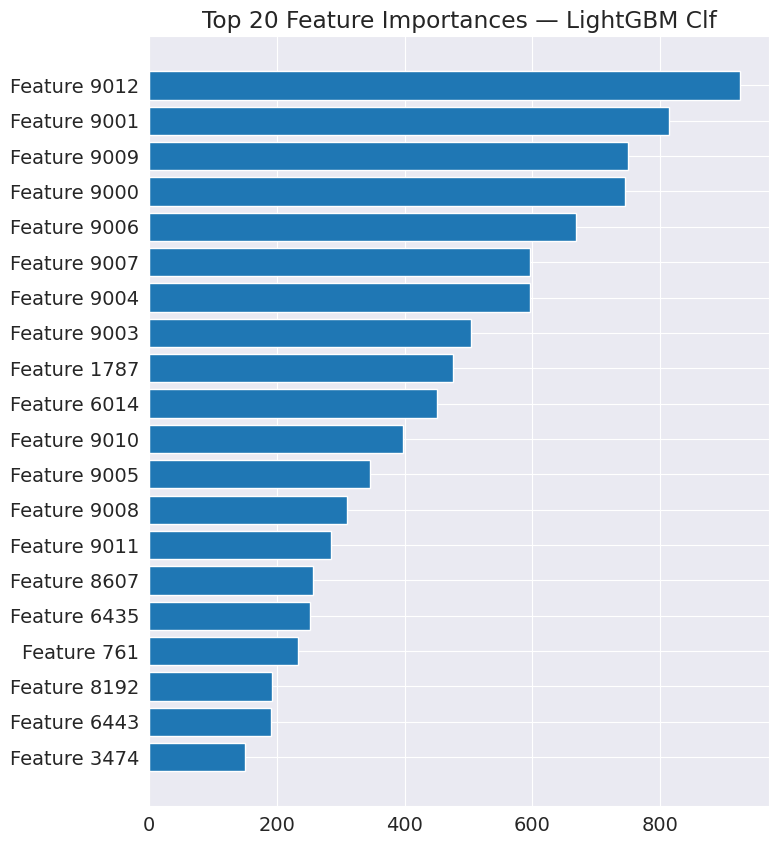

In [ ]:
importance = best_clf_fb.feature_importances_
idx = np.argsort(importance)[-20:]

plt.figure(figsize=(8, 10))
plt.barh(range(len(idx)), importance[idx])
plt.yticks(range(len(idx)), [f"Feature {i}" for i in idx])
plt.title("Top 20 Feature Importances — LightGBM Clf")
plt.show()

- Модель LightGBM показує, що найбільш важливими ознаками є TF‑IDF токени, які відповідають ключовим словам у заголовку. Це підтверджує, що текстова інформація є критичною для передбачення віральності.

### Confusion Matrix - BERT класифікація

In [ ]:
bert_preds = []
bert_probs = []

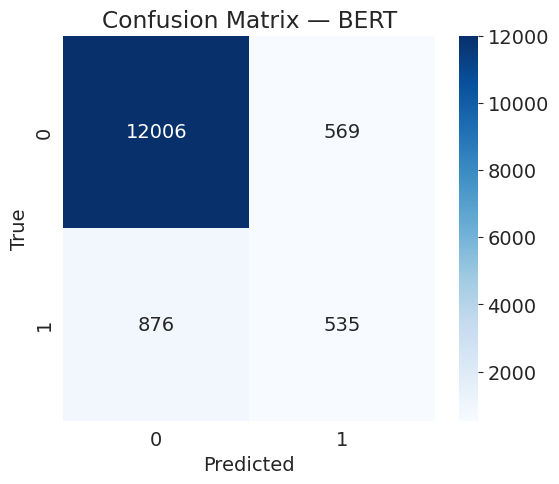

In [ ]:
cm = confusion_matrix(y_viral_val, bert_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — BERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### ROC-крива - BERT vs LightGBM

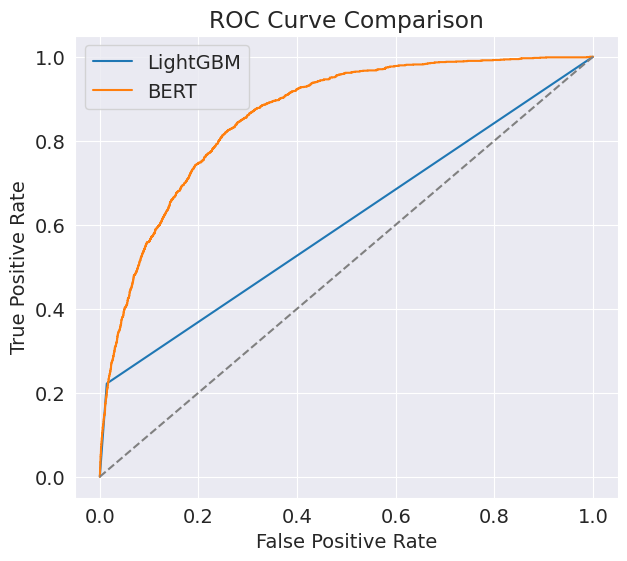

In [ ]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_viral_val, viral_val_pred)
fpr_bert, tpr_bert, _ = roc_curve(y_viral_val, bert_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lgb, tpr_lgb, label="LightGBM")
plt.plot(fpr_bert, tpr_bert, label="BERT")
plt.plot([0,1],[0,1],"--", color="gray")
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

- BERT має вищу AUC, що означає кращу здатність моделі відділяти позитивні приклади від негативних. Він стабільно дає вищий True Positive Rate при будь-якому False Positive Rate, що підтверджує його кращу здатність розрізняти класи. LightGBM працює стабільно, але не може вловити глибокі текстові патерни, які BERT обробляє природно.

#### Висновок

- Baseline - лише точка відліку. Він показує, що задача складна, і прості моделі не працюють.

- LGBM - спостерігається оверфіт на класифікації, однак він стабільний, непогано узагальнює, і дає найкращий RMSE.

- BERT - сильний регресор, недотренований класифікатор, потрібно спробувати DistiBert + додати більше ітерацій хоч 10.